## Project card

**The paper:**

Mossong et al. (2008), *Social Contacts and Mixing Patterns Relevant to the Spread of Infectious Diseases*. PLOS Medicine.

https://doi.org/10.1371/journal.pmed.0050074

**The data object:**

The participant counts, means and standard deviations for ages 10–14 and 70+ in Table 1. We use published summaries, not individual diary records.

**The random variable chosen:**

$X$ is the number of different people a randomly selected participant has contact with during one day. We model $X$ separately for the age groups 10–14 and 70+.

**What the paper does:**

The paper studies contact diaries from 7290 participants in eight European countries. It compares contact patterns between groups and uses age-specific patterns to model the early spread of an infection.

**The generative model proposed:**

We use a negative binomial distribution to simulate daily contact counts for each age group. People meet different numbers of people depending on their routines and daily activities, and their contact counts also vary by chance. The published variance is much larger than the mean in both groups. A negative binomial model allows for this, while a Poisson model assumes equal mean and variance and would give too little spread.

**Parameters and assumptions:**

For each group, $\mu$ is the average number of contacts per person per day in our model. The parameter $r$ is positive, has no units and controls how spread out the contact counts are. A higher $\mu$ means more contacts on average. A lower $r$ means more variation between people when $\mu$ stays the same.

We assume that participants' contact counts are independent and use the same distribution and parameters for everyone within each age group. We do not account for country, sex, household size or day of the week separately.

**The forward simulation:**

We simulate the number of daily contacts for 713 participants aged 10–14 and 270 aged 70+. We then repeat the survey 5,000 times to see how much the difference between the groups' average contact counts varies from one survey to another.

**The parameterization/fitting:**

We use the published mean as our estimate of $\mu$ and calculate $r$ from the published mean and standard deviation. We then calculate $p$ so we can use NumPy to simulate contact counts. We estimate the parameters first, then use them to run the simulations.

**What/if the model adds to the paper:**

Our model shows how much the difference between the groups' average contact counts can vary by chance when we simulate surveys with the same numbers of participants.

**Model limitations/how it breaks:**

People in the same household or school may have related contact patterns, but our model treats participants independently. Using one distribution for each age group may also miss differences within the group. Matching the published mean and variance does not mean that the model captures all contact patterns correctly. We also do not account for mistakes in reporting contacts or the possibility that the participants do not represent the wider population.

## Question and data

How much does the average number of daily contacts differ between people aged 10–14 and those aged 70+?

We use these values from Table 1 in the paper:

| Age group | Participants | Mean daily contacts | Standard deviation |
|---|---:|---:|---:|
| 10–14 | 713 | 18.22 | 12.27 |
| 70+ | 270 | 6.89 | 5.83 |

A contact means physical touch or a two-way, face-to-face conversation of at least three words. Each person met is counted only once per day.

In [212]:
import numpy as np
import matplotlib.pyplot as plt

# Makes the results reproducible when all cells are run in order
rng = np.random.default_rng(42)

In [213]:
# Published values from Table 1 in article

# Participants aged 10–14
n_young = 713
mean_young = 18.22
sd_young = 12.27

# Participants aged 70+
n_older = 270
mean_older = 6.89
sd_older = 5.83

observed_difference = mean_young - mean_older

print("Published difference:", round(observed_difference, 2), "contacts per day")

Published difference: 11.33 contacts per day


## Model equations

For each age group, the model's mean and variance are:

$$
E[X] = \mu, \qquad \mathrm{Var}(X) = \mu + \frac{\mu^2}{r}
$$

## Estimating the parameters

We use the published mean $m$ as our estimate of $\mu$. We calculate $r$ using that mean and the published standard deviation $s$:

$$
\hat{\mu} = m, \qquad \hat{r} = \frac{m^2}{s^2-m}
$$

These estimates give the model the same mean and variance as the published values. The formula for $r$ works when the variance is larger than the mean, which it is for both groups.

To simulate contact counts with NumPy, we also need $p$. We calculate it from $r$ and $\mu$:

$$
p = \frac{r}{r+\mu}
$$

In [214]:
def estimate_parameters(mean, sd):

    variance = sd ** 2
    r = mean ** 2 / (variance - mean)
    p = r / (r + mean)

    return r, p


r_young, p_young = estimate_parameters(mean_young, sd_young)
r_older, p_older = estimate_parameters(mean_older, sd_older)

print("Ages 10–14: mu =", mean_young, "r =", round(r_young, 2), "p =", round(p_young, 2))

print("Ages 70+: mu =", mean_older, "r =", round(r_older, 2), "p =", round(p_older, 2))

Ages 10–14: mu = 18.22 r = 2.51 p = 0.12
Ages 70+: mu = 6.89 r = 1.75 p = 0.2


## Simulating one survey

We use the estimated parameters to simulate daily contacts for the same number of participants as in the paper. We then compare the simulated mean and standard deviation with the published values. They should be fairly close, but some difference is expected because of the randomness in the simulation.

In [215]:
contacts_young = rng.negative_binomial(r_young, p_young, n_young)

contacts_older = rng.negative_binomial(r_older, p_older, n_older)

print("Ages 10–14:")
print("Published mean:", round(mean_young, 2))
print("Simulated mean:", round(np.mean(contacts_young), 2))
print("Published SD:", round(sd_young, 2))
print("Simulated SD:", round(np.std(contacts_young), 2))

print("\nAges 70+:")
print("Published mean:", round(mean_older, 2))
print("Simulated mean:", round(np.mean(contacts_older), 2))
print("Published SD:", round(sd_older, 2))
print("Simulated SD:", round(np.std(contacts_older), 2))

Ages 10–14:
Published mean: 18.22
Simulated mean: 18.29
Published SD: 12.27
Simulated SD: 12.03

Ages 70+:
Published mean: 6.89
Simulated mean: 6.63
Published SD: 5.83
Simulated SD: 5.73


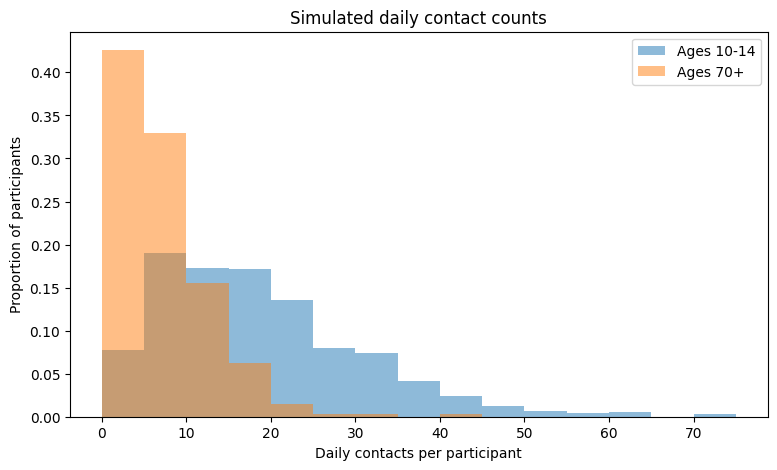

In [216]:
#use the same bins for both groups
max_contacts = max(contacts_young.max(), contacts_older.max())
bins = np.arange(0, max_contacts + 5, 5)

plt.figure(figsize=(9, 5))

#weights make the height show proportions instead of participant counts
plt.hist(contacts_young, bins=bins, weights=np.ones(n_young) / n_young, alpha=0.5, label="Ages 10-14")

plt.hist(contacts_older, bins=bins, weights=np.ones(n_older) / n_older, alpha=0.5, label="Ages 70+")

plt.xlabel("Daily contacts per participant")
plt.ylabel("Proportion of participants")
plt.title("Simulated daily contact counts")
plt.legend()
plt.show()

## Variation between repeated surveys

We simulate 5,000 surveys using the same estimated parameters and group sizes. Each time, we subtract the older group's mean from the younger group's mean. We then calculate the standard deviation and the middle 95% interval of these differences to see how much the result varies by chance under our model.

In [217]:
differences = []

for i in range(5000):
    simulated_young = rng.negative_binomial(r_young, p_young, n_young)
    simulated_older = rng.negative_binomial(r_older, p_older, n_older)

    difference = np.mean(simulated_young) - np.mean(simulated_older)
    differences.append(difference)

average_difference = np.mean(differences)
sd_difference = np.std(differences)
lower, upper = np.percentile(differences, [2.5, 97.5])

print("Published difference:", round(observed_difference, 2))
print("Mean simulated difference:", round(average_difference, 2))
print("SD of simulated differences:", round(sd_difference, 2))
print("Middle 95% of simulated differences:", round(lower, 2), "to", round(upper, 2))
print("Units: contacts per person per day")

Published difference: 11.33
Mean simulated difference: 11.34
SD of simulated differences: 0.59
Middle 95% of simulated differences: 10.18 to 12.48
Units: contacts per person per day


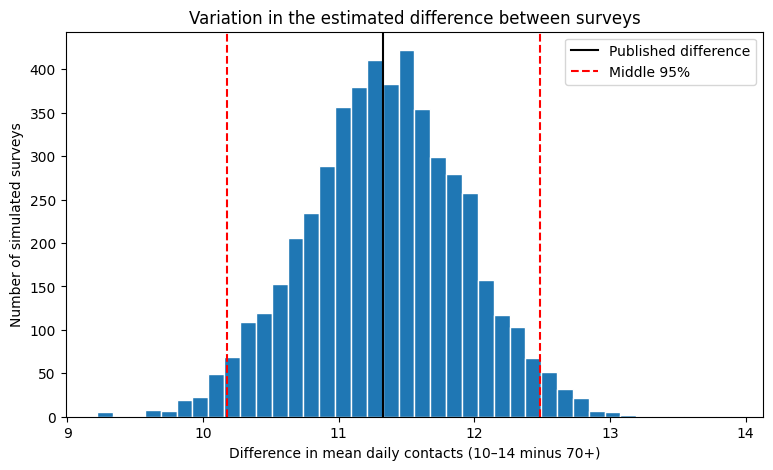

In [218]:
plt.figure(figsize=(9, 5))

plt.hist(differences, bins=40, edgecolor="white")

plt.axvline(observed_difference, color="black", label="Published difference")
plt.axvline(lower, color="red", linestyle="--", label="Middle 95%")
plt.axvline(upper, color="red", linestyle="--")

plt.xlabel("Difference in mean daily contacts (10–14 minus 70+)")
plt.ylabel("Number of simulated surveys")
plt.title("Variation in the estimated difference between surveys")
plt.legend()
plt.show()

## Results and interpretation

The published mean was 18.22 daily contacts for ages 10–14 and 6.89 for ages 70+, a difference of 11.33 contacts per person per day.

Across 5,000 simulated surveys, the mean difference was 11.34 contacts per person per day, with a standard deviation of 0.59. The middle 95% of the differences fell between 10.18 and 12.48. Under our fitted model, the variation between surveys was small compared with the difference between the age groups.

The results are close to the published difference because we fitted the model using the paper's means and standard deviations. The simulations show how much this difference can vary by chance with these group sizes.